# Counterfactual Generation using Nina's Model
### First attempt and exploration

In [4]:
import sys
from unittest.mock import MagicMock

# Stub problematic dependencies BEFORE importing anything from FastDiME
for mod_name in [
    'pytorch_lightning',
    'pytorch_lightning.core',
    'pytorch_lightning.core.lightning',
    'pytorch_lightning.core.module',
    'torchaudio'
]:
    sys.modules[mod_name] = MagicMock()

# Also block internal modules that trigger them
sys.modules['models.base_classifier'] = MagicMock()
sys.modules['models.resnet'] = MagicMock()
import os


In [5]:
# Set up paths and Directories
FASTDIME_PATH  = "/zhome/d0/a/221493/thesis/FastDiME_Med"      # path to Nina's repo
CHEXPERT_PATH  = "/zhome/d0/a/221493/thesis/data/CheXpert-v1.0-small"
RESULTS_PATH   = "/zhome/d0/a/221493/thesis/results"
PRETRAINED_DIR = os.path.join(FASTDIME_PATH, "pretrained_models")
DEVICE         = "cpu"   # or "cpu" for local testing without GPU
TARGET_DISEASE = "Effusion"   # must match what you ran in c0_run_diagnostic_predictions.py

In [6]:
sys.path.insert(0, FASTDIME_PATH)

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from tqdm import tqdm

import torchvision.transforms as T
from torchvision.utils import make_grid
import torchxrayvision as xrv

# Now we can safely import Nina's diffusion and UNet code
from models.unet import UNet
from models.diffusion import SimpleDiffusion, GuidedDiffusion
from train.utils import get

import sys
from unittest.mock import MagicMock

# ── Nina's modules — careful import to avoid pytorch_lightning/torchaudio chain
# The problem: models/diffusion.py imports models/resnet.py which imports
# base_classifier.py which imports pytorch_lightning which triggers torchaudio
# which crashes on CUDA version mismatch.
# Solution: patch sys.modules to stub out the problematic deps before importing.

# Stub out pytorch_lightning and torchaudio before anything tries to import them
for mod_name in [
    'pytorch_lightning', 'torchaudio',
    'pytorch_lightning.core', 'pytorch_lightning.core.lightning',
    'pytorch_lightning.core.module',
]:
    sys.modules[mod_name] = MagicMock()

# Also stub the base_classifier so ResNet import doesn't blow up
# (we don't need ResNet — our classifier is the xrv DenseNet)
sys.modules['models.base_classifier'] = MagicMock()
sys.modules['models.resnet'] = MagicMock()


torch.manual_seed(42)
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {DEVICE}")
print(f"CUDA ok  : {torch.cuda.is_available()}")
print("Imports OK — pytorch_lightning/torchaudio stubbed out (not needed for diffusion exploration)")

PyTorch  : 2.8.0+cu128
Device   : cpu
CUDA ok  : False
Imports OK — pytorch_lightning/torchaudio stubbed out (not needed for diffusion exploration)


---
## 2. The β Noise Schedule

The noise schedule defines *how fast* information is destroyed during the forward process. In Nina's repo it is a **linear schedule** — β increases linearly from ~0.0001 to ~0.02 over T=1000 steps.

From β, all other diffusion quantities are derived:

| Symbol | Formula | Meaning |
|--------|---------|--------|
| αₜ | 1 − βₜ | Signal retention at step t |
| ᾱₜ | ∏ᵢαᵢ | **Cumulative** signal retention from 0→t |
| √ᾱₜ | sqrt(ᾱₜ) | Scale factor on x₀ in the forward formula |
| √(1−ᾱₜ) | sqrt(1−ᾱₜ) | Scale factor on noise ε in the forward formula |

The key insight from the plot below: by t≈300, ᾱₜ is already very small — the original image signal is mostly gone. This is why `cf_from_timestep=200` is a reasonable choice: enough noise to allow edits, but not so much that the image identity is lost.

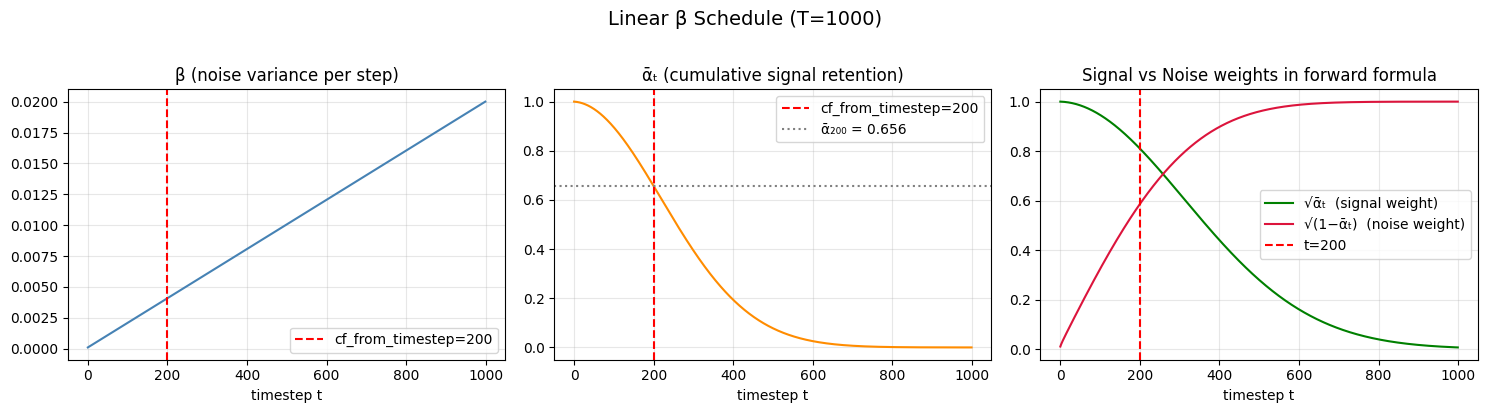

At t=200 : ᾱ = 0.6563  →  image signal weight = 0.8102, noise weight = 0.5862
At t=500 : ᾱ = 0.0778  →  image signal weight = 0.2789, noise weight = 0.9603
At t=999 : ᾱ = 0.0000  →  mostly pure noise


In [7]:
T = 1000
sd = SimpleDiffusion(num_diffusion_timesteps=T, device="cpu")

timesteps = torch.arange(T)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# β schedule
axes[0].plot(sd.beta.numpy(), color='steelblue')
axes[0].set_title('β (noise variance per step)', fontsize=12)
axes[0].set_xlabel('timestep t')
axes[0].axvline(200, color='red', linestyle='--', label='cf_from_timestep=200')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Cumulative ᾱ — signal remaining
axes[1].plot(sd.alpha_cumulative.numpy(), color='darkorange')
axes[1].set_title('ᾱₜ (cumulative signal retention)', fontsize=12)
axes[1].set_xlabel('timestep t')
axes[1].axvline(200, color='red', linestyle='--', label='cf_from_timestep=200')
axes[1].axhline(sd.alpha_cumulative[200].item(), color='gray', linestyle=':', 
                label=f'ᾱ₂₀₀ = {sd.alpha_cumulative[200].item():.3f}')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Signal vs noise fraction at each t
signal = sd.sqrt_alpha_cumulative.numpy()
noise  = sd.sqrt_one_minus_alpha_cumulative.numpy()
axes[2].plot(signal, color='green',  label='√ᾱₜ  (signal weight)')
axes[2].plot(noise,  color='crimson', label='√(1−ᾱₜ)  (noise weight)')
axes[2].axvline(200, color='red', linestyle='--', label='t=200')
axes[2].set_title('Signal vs Noise weights in forward formula', fontsize=12)
axes[2].set_xlabel('timestep t')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('Linear β Schedule (T=1000)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"At t=200 : ᾱ = {sd.alpha_cumulative[200]:.4f}  →  image signal weight = {sd.sqrt_alpha_cumulative[200]:.4f}, noise weight = {sd.sqrt_one_minus_alpha_cumulative[200]:.4f}")
print(f"At t=500 : ᾱ = {sd.alpha_cumulative[500]:.4f}  →  image signal weight = {sd.sqrt_alpha_cumulative[500]:.4f}, noise weight = {sd.sqrt_one_minus_alpha_cumulative[500]:.4f}")
print(f"At t=999 : ᾱ = {sd.alpha_cumulative[999]:.4f}  →  mostly pure noise")

---
## 3. Forward Diffusion — Corrupting a Real Image

The forward process has a **closed-form** — you can jump directly to any noise level t without iterating:

$$x_t = \sqrt{\bar{\alpha}_t} \cdot x_0 \;+\; \sqrt{1-\bar{\alpha}_t} \cdot \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, I)$$

This is what `SimpleDiffusion.forward_diffusion()` computes. Let's apply it to a real CheXpert image and see the degradation.

In [8]:
# ── Load one CheXpert image ───────────────────────────────────────────────────
# We use the valid split C0 results CSV so we get an image we already have predictions for
disease_tag = TARGET_DISEASE.lower().replace(" ", "_")
c0_csv_path = os.path.join(RESULTS_PATH, f"C0_baseline/{disease_tag}/valid_c0_{disease_tag}.csv")

c0_df = pd.read_csv(c0_csv_path)
print(f"Loaded {len(c0_df)} validation samples with C0 predictions")
print(c0_df[['path','prob','pred','true','correct']].head())

# Pick one correct and one incorrect prediction to compare later
sample_correct   = c0_df[c0_df['correct'] == 1].iloc[0]
sample_incorrect = c0_df[c0_df['correct'] == 0].iloc[0]
print(f"\nCorrect sample   : {sample_correct['path']}  (prob={sample_correct['prob']:.3f}, true={int(sample_correct['true'])})")
print(f"Incorrect sample : {sample_incorrect['path']}  (prob={sample_incorrect['prob']:.3f}, true={int(sample_incorrect['true'])})")

Loaded 202 validation samples with C0 predictions
                                                path      prob  pred  true  \
0  CheXpert-v1.0-small/valid/patient64541/study1/...  0.615238     0   1.0   
1  CheXpert-v1.0-small/valid/patient64542/study1/...  0.509363     0   0.0   
2  CheXpert-v1.0-small/valid/patient64543/study1/...  0.657029     1   1.0   
3  CheXpert-v1.0-small/valid/patient64544/study1/...  0.506830     0   0.0   
4  CheXpert-v1.0-small/valid/patient64545/study1/...  0.681022     1   1.0   

   correct  
0        0  
1        1  
2        1  
3        1  
4        1  

Correct sample   : CheXpert-v1.0-small/valid/patient64542/study1/view1_frontal.jpg  (prob=0.509, true=0)
Incorrect sample : CheXpert-v1.0-small/valid/patient64541/study1/view1_frontal.jpg  (prob=0.615, true=1)


In [9]:
def load_chexpert_image_for_diffusion(img_path_relative, base_dir, device='cpu'):
    """
    Load a CheXpert image and prepare it for Nina's diffusion pipeline.
    
    Nina's pipeline expects images in [-1, 1], shape (1, C, H, W), H=W=224.
    CheXpert images are grayscale. We replicate the channel to get (1, 1, 224, 224).
    """
    full_path = os.path.join(base_dir, "data", img_path_relative)
    img = Image.open(full_path).convert('L')  # greyscale
    img = img.resize((224, 224), Image.LANCZOS)
    img_np = np.array(img).astype(np.float32) / 255.0   # [0, 1]
    img_t  = torch.from_numpy(img_np).unsqueeze(0).unsqueeze(0)  # (1, 1, 224, 224)
    img_t  = img_t * 2.0 - 1.0   # [0,1] → [-1, 1]  (Nina's normalisation)
    return img_t.to(device)


base_thesis = "/zhome/d0/a/221493/thesis"
x0 = load_chexpert_image_for_diffusion(sample_correct['path'], base_thesis, device='cpu')
print(f"x0 shape : {x0.shape}")
print(f"x0 range : [{x0.min():.3f}, {x0.max():.3f}]")

x0 shape : torch.Size([1, 1, 224, 224])
x0 range : [-1.000, 1.000]


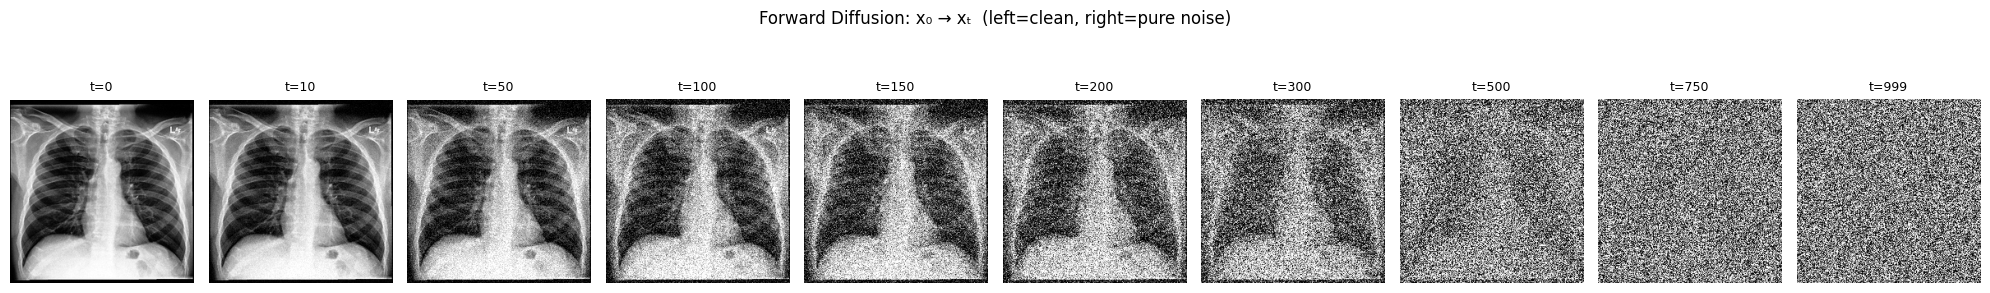


Observation: at t=200 the image is noisy but the chest structure is still recognisable.
This is why cf_from_timestep=200 gives the diffusion enough freedom to make edits
while keeping the CF anchored to the original patient anatomy.


In [ ]:
# ── Apply forward diffusion at multiple timesteps ─────────────────────────────
probe_timesteps = [0, 10, 50, 100, 150, 200, 300, 500, 750, 999]

fig, axes = plt.subplots(1, len(probe_timesteps), figsize=(20, 3))

for ax, t_val in zip(axes, probe_timesteps):
    t_tensor = torch.as_tensor(t_val, dtype=torch.long)
    x_t, _ = sd.forward_diffusion(x0, t_tensor)
    
    # Convert back to [0,1] for display
    img_display = ((x_t[0, 0].numpy() + 1) / 2).clip(0, 1)
    ax.imshow(img_display, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f't={t_val}', fontsize=9)
    ax.axis('off')

plt.suptitle('Forward Diffusion: x₀ → xₜ  (left=clean, right=pure noise)', fontsize=12, y=1.05)
plt.tight_layout()
plt.show()

print("\nObservation: at t=200 the image is noisy but the chest structure is still recognisable.")
print("This is why cf_from_timestep=200 gives the diffusion enough freedom to make edits")
print("while keeping the CF anchored to the original patient anatomy.")

---
## 4. The UNet — Loading the Pre-trained Noise Predictor

The UNet is the **learned** part of the diffusion model. It takes a noisy image `x_t` and a timestep `t`, and predicts the noise `ε` that was added. During training, it minimises:

$$\mathcal{L} = \mathbb{E}_{t, x_0, \varepsilon} \left[ \| \varepsilon - \varepsilon_\theta(x_t, t) \|^2 \right]$$

Nina's pre-trained model was trained on CheXpert images, so it has learned what realistic chest X-ray structure looks like at every noise level. This is the generative "backbone" we borrow — we do **not** retrain it.

In [10]:
# ── Load Nina's pre-trained diffusion UNet ────────────────────────────────────
# load_diffusion_model reads the checkpoint_dir from global_config.py inside the repo.
# If that isn't set up yet, you can load directly:

# Option A: use Nina's loader (requires global_config.py set up in the repo)
# checkpoint_dir = os.path.join(PRETRAINED_DIR, 'diffusion/CHEXPERT/')  # adjust path
# diffusion_model, diff_config = load_diffusion_model(checkpoint_dir=checkpoint_dir)

# Option B: manual load 
DIFFUSION_CKPT = os.path.join(PRETRAINED_DIR, "diffusion/OUT_CHEXPERT_CardioSplit/ckpt.tar")  # <-- update this

# Define the UNet architecture (must match what was used for training ???? )
diffusion_model = UNet(
    input_channels          = 1,
    output_channels         = 1,
    base_channels           = 64,
    base_channels_multiples = (1, 2, 4, 4),
    apply_attention         = (False, False, False, False),  # only bottleneck has attention
    dropout_rate            = 0.1,
    time_multiple           = 4,
)

# Load the checkpoint
ckpt = torch.load(DIFFUSION_CKPT, map_location='cpu')

# The checkpoint may nest the weights under 'model_state_dict' or 'state_dict'
state_dict = ckpt['model']

# Load the state dict into the model
diffusion_model.load_state_dict(state_dict)

# Set model to eval mode and move to device
diffusion_model.eval()
diffusion_model = diffusion_model.to(DEVICE)

# Print total parameters
total_params = sum(p.numel() for p in diffusion_model.parameters())
print(f"UNet loaded — {total_params/1e6:.1f}M parameters")


UNet loaded — 24.0M parameters


In [11]:
# ── Diffusion scheduler (noise schedule) ──────────────────────────────────────
from models.diffusion import SimpleDiffusion
from train.utils import get

sd = SimpleDiffusion(
    num_diffusion_timesteps=1000,
    img_shape=(1, 224, 224),
    device=DEVICE,
)
print("SimpleDiffusion scheduler ready")

SimpleDiffusion scheduler ready


Input x_t shape    : torch.Size([1, 1, 224, 224])
Predicted ε shape  : torch.Size([1, 1, 224, 224])
True ε range       : [-3.796, 4.070]
Predicted ε range  : [-3.798, 3.920]


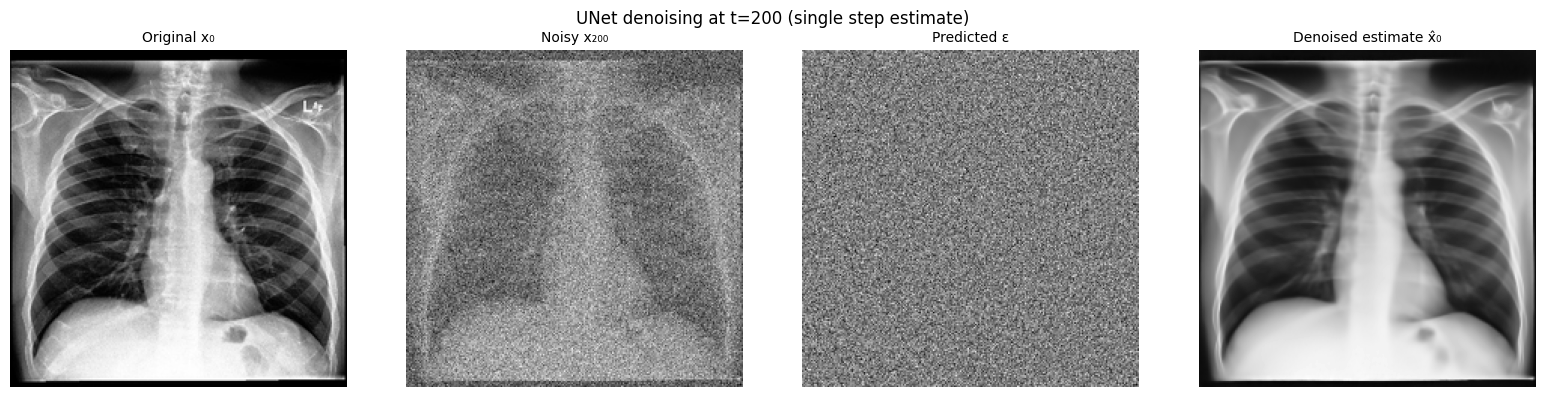


Note: the one-step estimate x̂₀ is blurry — that's expected.
In the full reverse process we chain many small steps, each refining the image.


In [ ]:
# ── Quick sanity check: UNet forward pass ─────────────────────────────────────
# Feed a noisy image at t=200, get predicted noise back
t_test   = torch.tensor([200], dtype=torch.long).to(DEVICE)
x0_gpu   = x0.to(DEVICE)

with torch.no_grad():
    x_200, true_noise = sd.forward_diffusion(x0_gpu, t_test)
    pred_noise = diffusion_model(x_200, t_test)

print(f"Input x_t shape    : {x_200.shape}")
print(f"Predicted ε shape  : {pred_noise.shape}")
print(f"True ε range       : [{true_noise.min():.3f}, {true_noise.max():.3f}]")
print(f"Predicted ε range  : [{pred_noise.min():.3f}, {pred_noise.max():.3f}]")

# Compute one-step denoised estimate x̂₀ from the predicted noise
# Formula 9 in Improved DDPM paper: x̂₀ = (xₜ - √(1-ᾱₜ)·ε) / √ᾱₜ
sqrt_alpha_bar_t = get(sd.sqrt_alpha_cumulative.to(DEVICE), t_test)
sqrt_1m_alpha_bar_t = get(sd.sqrt_one_minus_alpha_cumulative.to(DEVICE), t_test)
x0_hat = (x_200 - sqrt_1m_alpha_bar_t * pred_noise) / sqrt_alpha_bar_t

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
imgs = [
    (x0_gpu[0,0].cpu().numpy(),      "Original x₀"),
    (x_200[0,0].cpu().numpy(),        "Noisy x₂₀₀"),
    (pred_noise[0,0].cpu().numpy(),   "Predicted ε"),
    (x0_hat[0,0].cpu().numpy(),       "Denoised estimate x̂₀"),
]
for ax, (img, title) in zip(axes, imgs):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=10)
    ax.axis('off')
plt.suptitle('UNet denoising at t=200 (single step estimate)', fontsize=12)
plt.tight_layout()
plt.show()


**Original X_0** = My chest X-ray image, "ground truth", clean image;

**Noisy x_200** = At t=200 out of 1000, it's only 20% into the noise schedule so the X-ray is still recognisable;

**Predicted noise ε** = UNET takes the noisy image and the timestep and predicts what noise was added;

**Denoised estimate ^X_0** = Using the formula from Nina's FASTDiMe paper, you rearrange the forward formula to solve for x₀ *using the predicted noise instead of the true noise*. This is a single-step estimate — blurry because one step of denoising is a rough approximation. 

> So t=200 means "a specific, fixed ratio of image to noise" — not random, deterministic given t. That's what "belonging at that timestep" means. The model was trained on millions of examples of (noisy image at t, noise that was added), so when you show it x₂₀₀ and say t=200, it knows roughly how much noise to expect and can make a reasonable guess at what it was.

---
## 5. Reverse Diffusion — From Noise to Image (Unguided)

The reverse process iterates from t=T to t=0, applying the DDPM update at each step:

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}} \varepsilon_\theta(x_t, t) \right) + \sqrt{\beta_t} \cdot z$$

where $z \sim \mathcal{N}(0,I)$ (except at t=1 where z=0).

Without guidance this just samples a *random* image from the learned distribution. With **partial noising** (starting from a real image corrupted to t=200 rather than pure noise), the process *reconstructs* that image — with some variation. This is the starting mechanism for CF generation.

Reverse diffusion: 100%|██████████| 200/200 [07:15<00:00,  2.18s/it]


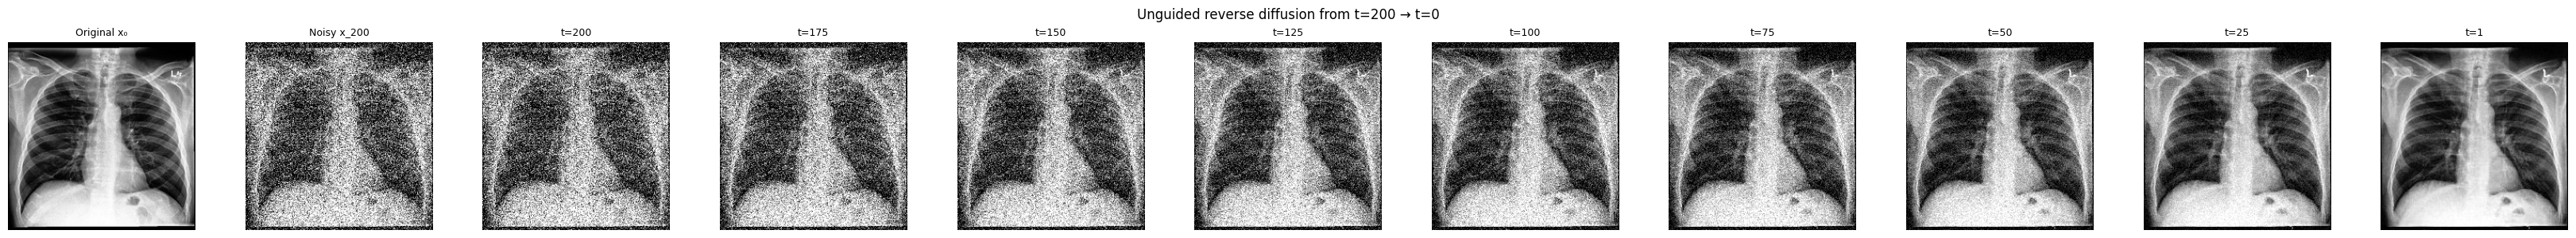


Key point: starting from a partially-noised real image (not pure noise)
the reverse process reconstructs the image — with slight variation.
Classifier guidance will steer this variation toward the target class.


In [ ]:
def reverse_diffusion_from_xt(model, sd, x_t_start, t_start, device='cpu', record_every=20):
    """
    Run the reverse diffusion from x_{t_start} back to x_0.
    Returns the final image and a list of intermediate images for visualisation.
    """
    model.eval()
    x = x_t_start.clone().to(device)
    intermediates = []

    for t_val in tqdm(reversed(range(1, t_start + 1)), total=t_start, desc='Reverse diffusion'):
        t_tensor = torch.ones(1, dtype=torch.long, device=device) * t_val
        z = torch.randn_like(x) if t_val > 1 else torch.zeros_like(x)

        with torch.no_grad():
            eps_pred = model(x, t_tensor)

        beta_t          = get(sd.beta.to(device), t_tensor)
        one_by_sqrt_a_t = get(sd.one_by_sqrt_alpha.to(device), t_tensor)
        sqrt_1m_abar_t  = get(sd.sqrt_one_minus_alpha_cumulative.to(device), t_tensor)

        x = one_by_sqrt_a_t * (x - (beta_t / sqrt_1m_abar_t) * eps_pred) + torch.sqrt(beta_t) * z

        if t_val % record_every == 0 or t_val == 1:
            intermediates.append((t_val, x[0, 0].cpu().numpy().copy()))

    return x, intermediates


# ── Partially noise to t=200, then reverse ────────────────────────────────────
CF_FROM_T = 200
t_tensor  = torch.tensor([CF_FROM_T], dtype=torch.long)
x_200, _  = sd.forward_diffusion(x0_gpu, t_tensor)

x_reconstructed, intermediates = reverse_diffusion_from_xt(
    diffusion_model, sd, x_200, CF_FROM_T, device=DEVICE, record_every=25
)

# ── Visualise the trajectory ──────────────────────────────────────────────────
n = len(intermediates)
fig, axes = plt.subplots(1, n + 2, figsize=(3 * (n + 2), 3))

axes[0].imshow(((x0_gpu[0,0].cpu().numpy() + 1)/2).clip(0,1), cmap='gray')
axes[0].set_title('Original x₀', fontsize=9)
axes[0].axis('off')

axes[1].imshow(((x_200[0,0].cpu().numpy() + 1)/2).clip(0,1), cmap='gray')
axes[1].set_title(f'Noisy x_{CF_FROM_T}', fontsize=9)
axes[1].axis('off')

for ax, (t_val, img) in zip(axes[2:], intermediates):
    ax.imshow(((img + 1)/2).clip(0,1), cmap='gray')
    ax.set_title(f't={t_val}', fontsize=9)
    ax.axis('off')

plt.suptitle(f'Unguided reverse diffusion from t={CF_FROM_T} → t=0', fontsize=12)
plt.tight_layout()
plt.show()

print("\nKey point: starting from a partially-noised real image (not pure noise)")
print("the reverse process reconstructs the image — with slight variation.")
print("Classifier guidance will steer this variation toward the target class.")

> The loop steps from t=200 down to t=1, one timestep at a time. At each step:

- The UNet predicts the noise ε̂ in the current image
- We apply the DDPM reverse formula to get x_{t-1} from x_t
- We add a tiny bit of fresh randomness z (except at the very last step where z=0 — no noise added at t=1 since you want a clean final image)

---
## 6. Partial Noising — Using different t_start values

The choice of `cf_from_timestep` is an ** important hyperparameter** for counterfactual quality:

- **Too low (t=50):** Not enough noise injected → diffusion can barely modify the image → low flip rate
- **Too high (t=600):** Too much noise → image identity destroyed → medically implausible CF
- **Sweet spot (~150-250):** Enough freedom to flip the classifier, but anatomy is preserved

Compare reconstructions at different `t_start` values, without guidance:

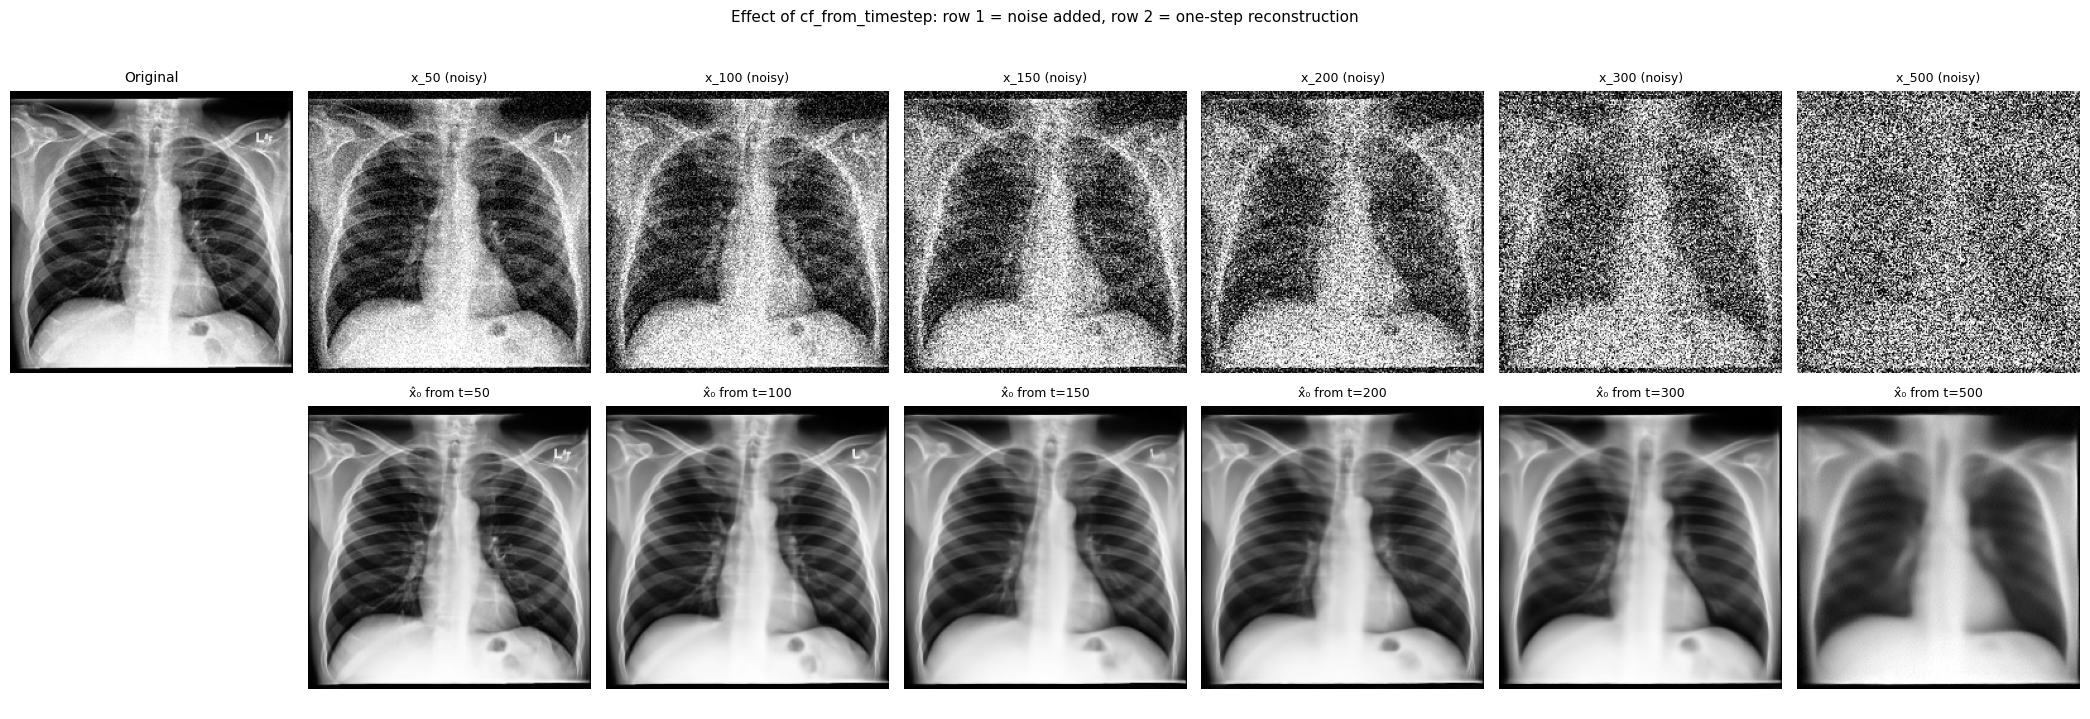

Higher t_start → noisier starting point → more potential for change → more risk of losing anatomy


In [ ]:
# ── Compare reconstructions at different t_start values ──────────────────────
t_starts = [50, 100, 150, 200, 300, 500]

fig, axes = plt.subplots(2, len(t_starts) + 1, figsize=(3 * (len(t_starts) + 1), 7))

# Original in the first column
orig_img = ((x0_gpu[0,0].cpu().numpy() + 1)/2).clip(0,1)
axes[0, 0].imshow(orig_img, cmap='gray')
axes[0, 0].set_title('Original', fontsize=10)
axes[0, 0].axis('off')
axes[1, 0].axis('off')

for col, t_s in enumerate(t_starts, start=1):
    t_t = torch.tensor([t_s], dtype=torch.long)
    x_noisy, _ = sd.forward_diffusion(x0_gpu, t_t)
    
    # Show noisy version
    axes[0, col].imshow(((x_noisy[0,0].cpu().numpy()+1)/2).clip(0,1), cmap='gray')
    axes[0, col].set_title(f'x_{t_s} (noisy)', fontsize=9)
    axes[0, col].axis('off')
    
    # Reconstruct (fast: just one-step estimate for comparison)
    with torch.no_grad():
        eps_pred = diffusion_model(x_noisy.to(DEVICE), t_t.to(DEVICE))
    sqrt_ab = get(sd.sqrt_alpha_cumulative.to(DEVICE), t_t.to(DEVICE))
    sqrt_1mab = get(sd.sqrt_one_minus_alpha_cumulative.to(DEVICE), t_t.to(DEVICE))
    x0_est = (x_noisy.to(DEVICE) - sqrt_1mab * eps_pred) / sqrt_ab
    
    axes[1, col].imshow(((x0_est[0,0].cpu().numpy()+1)/2).clip(0,1), cmap='gray')
    axes[1, col].set_title(f'x̂₀ from t={t_s}', fontsize=9)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Noisy', fontsize=10)
axes[1, 0].set_ylabel('Reconstructed', fontsize=10)

plt.suptitle('Effect of cf_from_timestep: row 1 = noise added, row 2 = one-step reconstruction', 
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()



## 7. Classifier Guidance — Steering the Generation

In [20]:
def guided_reverse_step(model, sd, x_t, t_val, classifier, target_class_idx, 
                       guidance_weight, device):
    """
    One step of classifier-guided reverse diffusion using the x0-hat trick.
    """

    t_tensor = torch.ones(1, dtype=torch.long, device=device) * t_val

    # ── Step 1: UNet noise prediction (no grad needed) ─────────────────────
    with torch.no_grad():
        eps_pred = model(x_t, t_tensor)

    # ── Step 2: compute x0_hat (no grad, for DDPM update) ──────────────────
    sqrt_abar   = get(sd.sqrt_alpha_cumulative.to(device), t_tensor)
    sqrt_1mabar = get(sd.sqrt_one_minus_alpha_cumulative.to(device), t_tensor)

    with torch.no_grad():
        x0_hat = (x_t - sqrt_1mabar * eps_pred) / sqrt_abar
        x0_hat = x0_hat.clamp(-1, 1)

    # ── Step 3: recompute WITH grad for classifier guidance ───────────────
    x_t_with_grad = x_t.detach().requires_grad_(True)
    eps_pred_grad = model(x_t_with_grad, t_tensor)

    x0_hat_grad = (x_t_with_grad - sqrt_1mabar * eps_pred_grad) / sqrt_abar
    x0_hat_grad = x0_hat_grad.clamp(-1, 1)

    # ── Step 4: prepare image for classifier ──────────────────────────────
    # [-1,1] → [0,1]
    x0_hat_img = (x0_hat_grad + 1) / 2

    # grayscale → 3-channel
    x0_hat_3ch = x0_hat_img.repeat(1, 3, 1, 1)

    # normalize like training
    mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1,3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1,3,1,1)
    x0_hat_3ch = (x0_hat_3ch - mean) / std

    # ── Step 5: classifier log-prob ───────────────────────────────────────
    logits = classifier(x0_hat_3ch).squeeze()

    if target_class_idx == 1:  # disease present
        log_prob = torch.log(torch.sigmoid(logits))
    else:  # disease absent
        log_prob = torch.log(1 - torch.sigmoid(logits))

    # ── Step 6: gradient w.r.t x_t ────────────────────────────────────────
    grad = torch.autograd.grad(log_prob, x_t_with_grad)[0]

    # ── Step 7: DDPM reverse step + guidance ──────────────────────────────
    beta_t         = get(sd.beta.to(device), t_tensor)
    one_by_sqrt_at = get(sd.one_by_sqrt_alpha.to(device), t_tensor)
    z = torch.randn_like(x_t) if t_val > 1 else torch.zeros_like(x_t)

    x_prev = (
        one_by_sqrt_at * (x_t - (beta_t / sqrt_1mabar) * eps_pred)
        + guidance_weight * grad
        + torch.sqrt(beta_t) * z
    )

    return x_prev.detach()

In [21]:
def generate_counterfactual(model, sd, x0, t_start, classifier, target_class_idx,
                             guidance_weight, device='cpu', record_every=20):
    
    """Generate a counterfactual by running guided reverse diffusion from x_{t_start}.
    Args:
    - model: pretrained UNet noise predictor
    - sd: diffusion scheduler (SimpleDiffusion)
    - x0: original clean image 
    - t_start: timestep to start reverse diffusion from (e.g. 200)
    - classifier: pretrained DenseNet121 for guidance
    - target_class_idx: index of the target disease in classifier.pathologies
    - guidance_weight: how strongly to push toward target class (try 1-3)
    - device: 'cuda' or 'cpu'
    - record_every: how often to save intermediate images for visualisation
    Returns:
    - final counterfactual image (x0_hat at t=0)
    - classifier probability of target class on final CF
    - list of intermediate images (timestep, image) for visualisation
    """
    
    model.eval()
    
    # Forward diffusion: corrupt x0 to x_{t_start}
    t_tensor = torch.tensor([t_start], dtype=torch.long).to(device)
    x, _ = sd.forward_diffusion(x0.to(device), t_tensor)
    
    intermediates = []

    for t_val in tqdm(reversed(range(1, t_start + 1)), total=t_start, desc='Guided reverse diffusion'):
        x = guided_reverse_step(model, sd, x, t_val, classifier, target_class_idx, 
                                guidance_weight, device)
        if t_val % record_every == 0 or t_val == 1:
            intermediates.append((t_val, x[0, 0].cpu().numpy().copy()))
    
    # Classifier probability on final CF
    with torch.no_grad():
        x_cf_3ch = x.repeat(1, 3, 1, 1)
        logits = classifier(x_cf_3ch)
        cf_prob = torch.sigmoid(logits)[0, target_class_idx].item()
    
    return x, cf_prob, intermediates

In [22]:
# Load the dataset we created for training the custom classifier (C2)
import pandas as pd
val_set = pd.read_csv("/zhome/d0/a/221493/thesis/results/C0_custom/effusion/val_c0_effusion.csv")
val_set

KeyboardInterrupt: 

In [23]:
# Choose an image
positive_sample = val_set[val_set['true'] == 1].sample(n=1)

In [24]:
print("Selected positive sample for counterfactual generation:")
print(positive_sample[['path', 'prob', 'pred', 'true', 'correct']])

Selected positive sample for counterfactual generation:
                                                   path      prob  pred  true  \
9153  CheXpert-v1.0-small/train/patient07978/study20...  0.982424     1   1.0   

      correct  
9153        1  


In [25]:
from torchvision import models
import torch
import torch.nn as nn

def load_c0_classifier(model_path, device):
    model = models.densenet121()
    model.classifier = nn.Linear(model.classifier.in_features, 1)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()
    return model

MODEL_PATH = "/zhome/d0/a/221493/thesis/results/C0_custom/c0_best.pt"
DEVICE = "cpu"  # or "cuda" if you have GPU access
classifier = load_c0_classifier(MODEL_PATH, DEVICE)

In [26]:
classifier = load_c0_classifier(MODEL_PATH, DEVICE)

x_cf, cf_prob, intermediates = generate_counterfactual(
    diffusion_model,
    sd,
    x0,
    t_start=200,
    classifier=classifier,
    target_class_idx=1,  # 1 = Effusion present
    guidance_weight=2.0,
    device=DEVICE
)

print("Counterfactual probability:", cf_prob)

Guided reverse diffusion: 100%|██████████| 200/200 [23:21<00:00,  7.01s/it]


IndexError: index 1 is out of bounds for dimension 1 with size 1

In [27]:
# Display original, CF, and intermediates
fig, axes = plt.subplots(1, len(intermediates) + 2, figsize=(3 * (len(intermediates) + 2), 3))
axes[0].imshow(((x0[0,0].cpu().numpy() + 1)/2).clip(0,1), cmap='gray')
axes[0].set_title('Original x₀', fontsize=9)
axes[0].axis('off')
axes[1].imshow(((x_cf[0,0].cpu().numpy() + 1)/2).clip(0,1), cmap='gray')
axes[1].set_title('Counterfactual x₀', fontsize=9)
axes[1].axis('off')
for ax, (t_val, img) in zip(axes[2:], intermediates):
    ax.imshow(((img + 1)/2).clip(0,1), cmap='gray')
    ax.set_title(f't={t_val}', fontsize=9)
    ax.axis('off')
plt.suptitle('Counterfactual Generation via Classifier-Guided Diffusion', fontsize=12)
plt.tight_layout()
plt.show()

NameError: name 'intermediates' is not defined

In [28]:
x

NameError: name 'x' is not defined